# ggh4x — Miscellaneous

Python port of the ggh4x **Miscellaneous** vignette on `ggplot2_py`: multiple colour/fill scales in one plot, extra geoms (point-path, polygon-raster, aimed text, tile-margin), and coord/position helpers.

In [1]:
import numpy as np, pandas as pd
from ggplot2_py import (ggplot, aes, geom_point, geom_raster, geom_bar, facet_wrap,
                        coord_fixed, coord_polar, coord_cartesian, theme, theme_void,
                        element_line, position_fill, scale_x_discrete,
                        scale_fill_distiller, scale_fill_brewer, scale_colour_brewer,
                        scale_fill_viridis_c)
from ggh4x import (scale_colour_multi, scale_listed, geom_tilemargin, geom_pointpath,
                   geom_polygonraster, geom_text_aimed, position_lineartrans, coord_axes_inside,
                   guide_stringlegend)
from ggh4x._datasets import load_iris, load_mtcars, load_pressure, load_volcano, mpg, diamonds

iris = load_iris()
setosa = iris[iris["Species"] == "setosa"]; versi = iris[iris["Species"] == "versicolor"]; virg = iris[iris["Species"] == "virginica"]

# correlation heatmap data (cor across the 4 iris measurements per flower)
iris_df = iris.copy(); iris_df["id"] = np.arange(1, len(iris) + 1)
X = iris[["Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width"]].to_numpy()
cc = np.corrcoef(X); n = cc.shape[0]
corr_df = pd.DataFrame({"x": np.tile(np.arange(1, n + 1), n), "y": np.repeat(np.arange(1, n + 1), n),
                        "correlation": cc.flatten(order="F")})

pressure = load_pressure()

# downsampled volcano grid keeps the polygon-raster render fast
vol = load_volcano()[::4, ::4]; nr, nc = vol.shape
dfv = pd.DataFrame({"x": np.tile(np.arange(1, nr + 1), nc), "y": np.repeat(np.arange(1, nc + 1), nr),
                    "value": vol.flatten(order="F")})

mt = load_mtcars().copy(); mt["car"] = mt.index.astype(str); mt = mt.reset_index(drop=True)
mt["cyl_f"] = mt["cyl"].astype(str)
mpg_rng = mt["mpg"].max() + mt["mpg"].min(); wt_rng = mt["wt"].max() + mt["wt"].min()

mpg2 = mpg.copy(); mpg2["f1"] = "1"
diam = diamonds.sample(3000, random_state=0)
mpg3 = mpg.copy(); mpg3["dx"] = mpg3["displ"] - mpg3["displ"].mean(); mpg3["dy"] = mpg3["hwy"] - mpg3["hwy"].mean()

## Multiple colour scales — `scale_colour_multi`

Give different layers their own colour aesthetic (`swidth`/`pleng`/`pwidth`) and map each through its own gradient:

/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/ggplot2-python/ggplot2_py/layer.py:943: UserWarning: Ignoring unknown aesthetics: `swidth`
  cli_warn(
/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/ggplot2-python/ggplot2_py/layer.py:943: UserWarning: Ignoring unknown aesthetics: `pleng`
  cli_warn(
/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/ggplot2-python/ggplot2_py/layer.py:943: UserWarning: Ignoring unknown aesthetics: `pwidth`
  cli_warn(


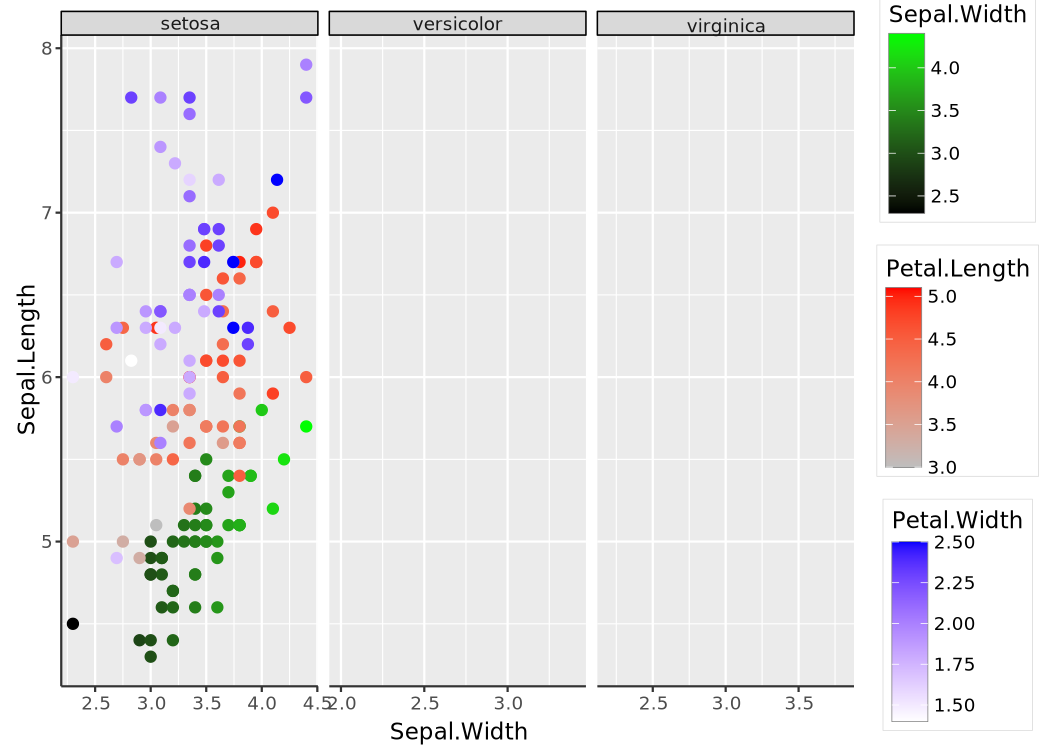

In [2]:
g = (ggplot(iris, aes("Sepal.Width", "Sepal.Length"))
     + geom_point(aes(swidth="Sepal.Width"), data=setosa)
     + geom_point(aes(pleng="Petal.Length"), data=versi)
     + geom_point(aes(pwidth="Petal.Width"), data=virg)
     + facet_wrap("Species", scales="free_x"))
g + scale_colour_multi(aesthetics=["swidth", "pleng", "pwidth"],
                       colours=[["black", "green"], ["gray", "red"], ["white", "blue"]])

## Several listed scales — `scale_listed`

Attach a list of scales, each replacing a chosen aesthetic. Here a `RdBu` correlation raster sits behind a `Set1` species margin:

In [3]:
gh = (ggplot(iris_df, aes("id", "id"))
      + geom_tilemargin(aes(species="Species"))
      + geom_raster(aes("x", "y", cor="correlation"), data=corr_df)
      + coord_fixed())
gh + scale_listed(scalelist=[scale_fill_distiller(palette="RdBu", aesthetics="cor"),
                             scale_fill_brewer(palette="Set1", aesthetics="species")],
                  replaces=["fill", "fill"])

/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/ggplot2-python/ggplot2_py/layer.py:943: UserWarning: Ignoring unknown aesthetics: `species`
  cli_warn(
/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/ggplot2-python/ggplot2_py/layer.py:943: UserWarning: Ignoring unknown aesthetics: `cor`
  cli_warn(


/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/ggplot2-python/ggplot2_py/plot.py:547: UserWarning: Failed to render ggplot via _repr_png_: ValueError: not enough values to unpack (expected 2, got 1)
Traceback (most recent call last):
  File "/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/ggplot2-python/ggplot2_py/plot.py", line 535, in _repr_png_
    grid_draw(gtable)
  File "/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/rgrid-python/grid_py/_draw.py", line 1122, in grid_draw
    _draw_gtree(x)
  File "/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/rgrid-python/grid_py/_draw.py", line 988, in _draw_gtree
    grid_draw(child, recording=False)
  File "/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/rgrid-python/grid_py/_draw.py", line 1122, in grid_draw
    _draw_gtree(x)
  File "/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/rgrid-python/grid_py/_draw.py", line 988, in _draw_gtree

<GGPlot data=150x6 layers=2>

## String legend — `guide_stringlegend`

A legend that lays the key labels out as text. Requested via the scale's `guide=` argument:

In [4]:
ggplot(diam, aes("price", "carat", colour="clarity")) + geom_point(shape=".") + scale_colour_brewer(palette="Dark2", guide=guide_stringlegend())

/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/ggplot2-python/ggplot2_py/plot.py:547: UserWarning: Failed to render ggplot via _repr_png_: ValueError: invalid literal for int() with base 10: '.'
Traceback (most recent call last):
  File "/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/ggplot2-python/ggplot2_py/plot.py", line 535, in _repr_png_
    grid_draw(gtable)
  File "/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/rgrid-python/grid_py/_draw.py", line 1122, in grid_draw
    _draw_gtree(x)
  File "/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/rgrid-python/grid_py/_draw.py", line 988, in _draw_gtree
    grid_draw(child, recording=False)
  File "/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/rgrid-python/grid_py/_draw.py", line 1122, in grid_draw
    _draw_gtree(x)
  File "/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/rgrid-python/grid_py/_draw.py", line 988, in _draw_gtree
   

<GGPlot data=3000x10 layers=1>

## Point-paths — `geom_pointpath`

A path with a point at every vertex and a small gap around each point (`mult` scales the gap):

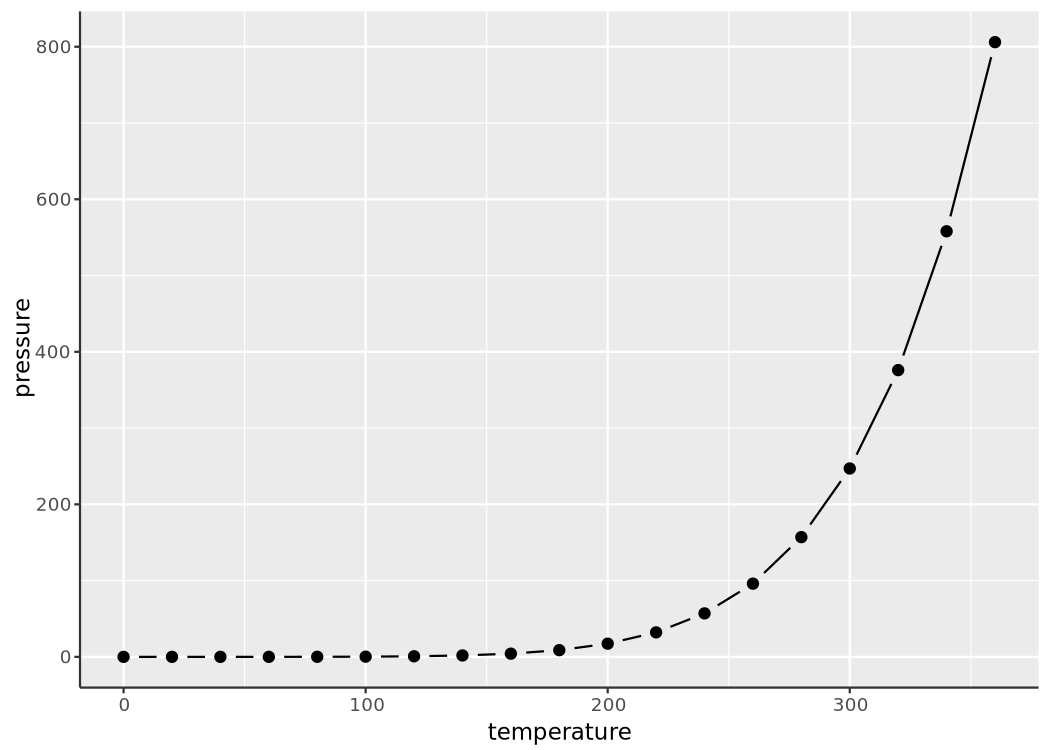

In [5]:
ggplot(pressure, aes("temperature", "pressure")) + geom_pointpath()

/home/groups/xiaojie/nianping/projects/Biobabel/Bio-Babel-public/ggplot2-python/ggplot2_py/layer.py:932: UserWarning: Ignoring unknown parameters: `linesize`
  cli_warn(


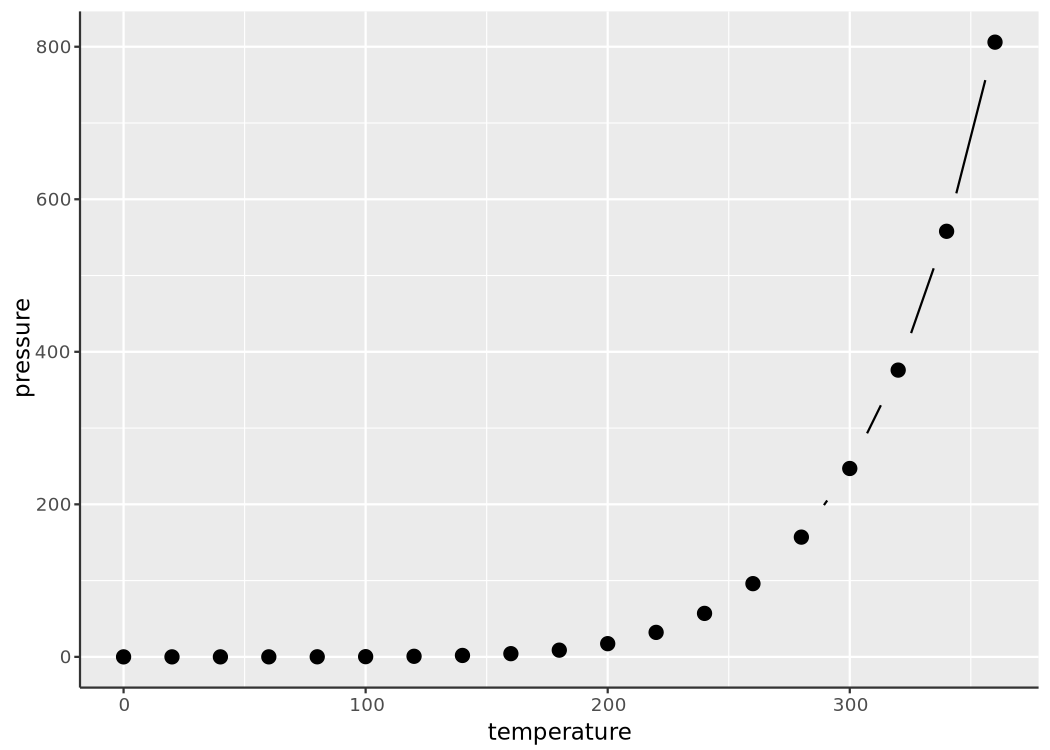

In [6]:
ggplot(pressure, aes("temperature", "pressure")) + geom_pointpath(linesize=2, size=2, mult=1)

## Polygon raster + linear-transform position

`geom_polygonraster` draws each raster cell as a polygon, so a `position_lineartrans` (shear / rotation) can warp the grid:

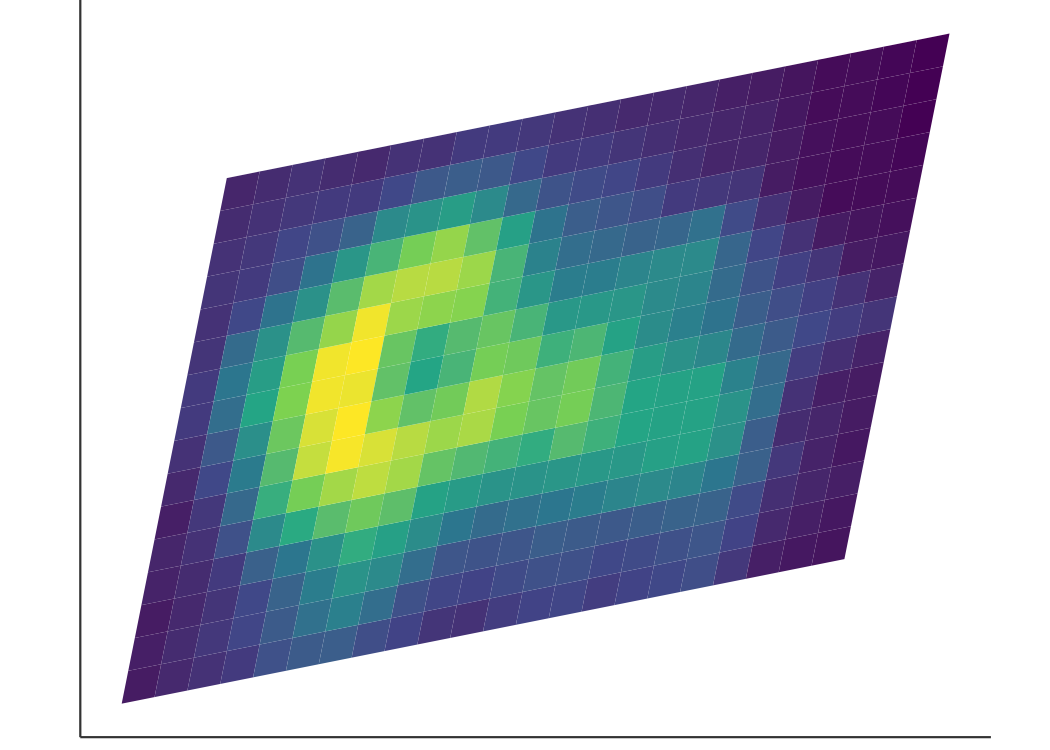

In [7]:
gv = ggplot(dfv, aes("x", "y", fill="value")) + scale_fill_viridis_c(guide="none") + theme_void()
gv + geom_polygonraster(position=position_lineartrans(shear=[0.2, 0.2])) + coord_fixed()

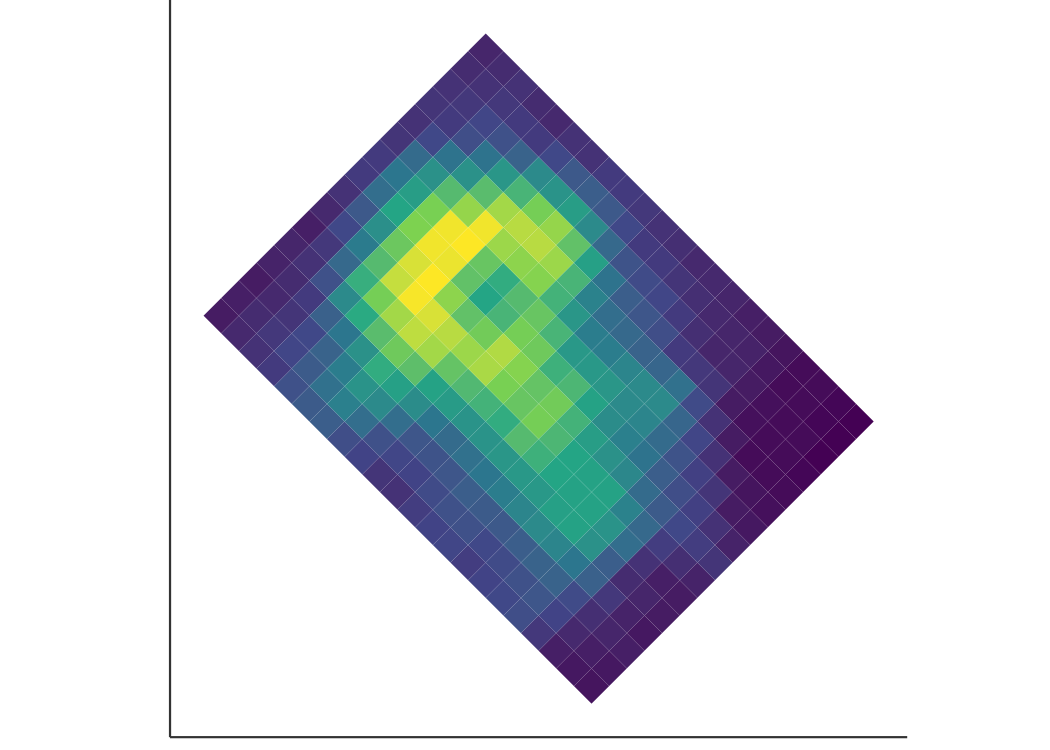

In [8]:
gv + geom_polygonraster(position=position_lineartrans(angle=45)) + coord_fixed()

## Aimed text — `geom_text_aimed`

Text rotated to *aim* at a target point (`xend`/`yend`); here every car label points at the plot centre:

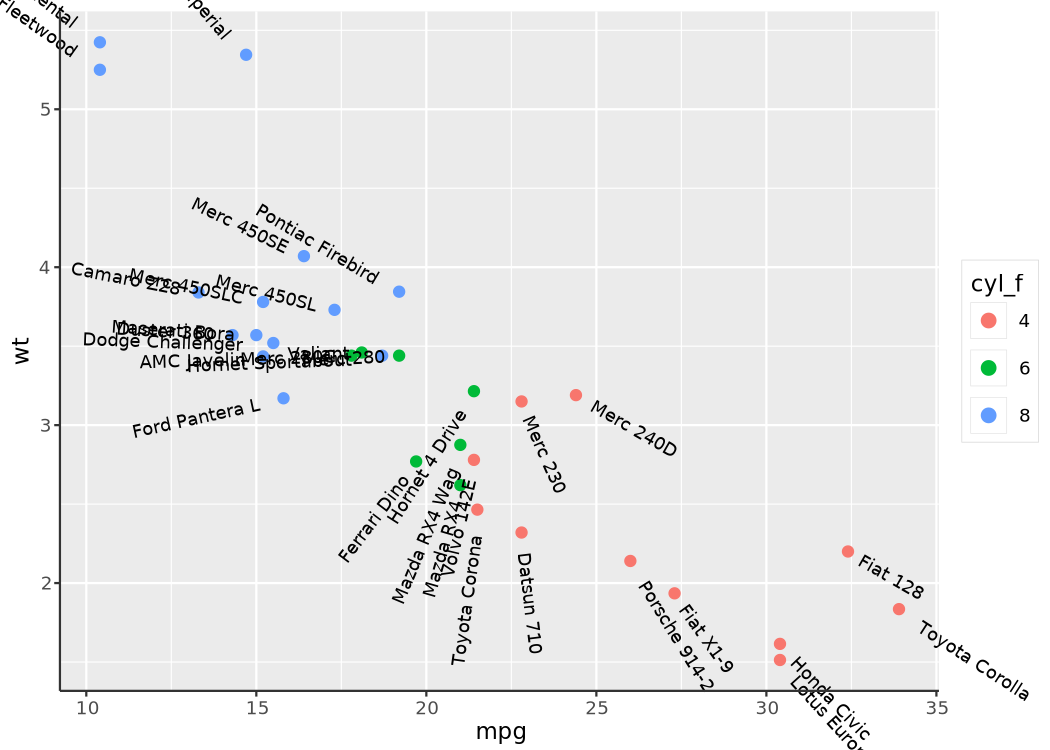

In [9]:
ggplot(mt, aes("mpg", "wt")) + geom_point(aes(colour="cyl_f")) + geom_text_aimed(aes(label="car"), hjust=-0.2, size=3, xend=mpg_rng / 2, yend=wt_rng / 2) + coord_cartesian(clip="off")

Aimed text shines in polar coordinates — labels follow the wedges:

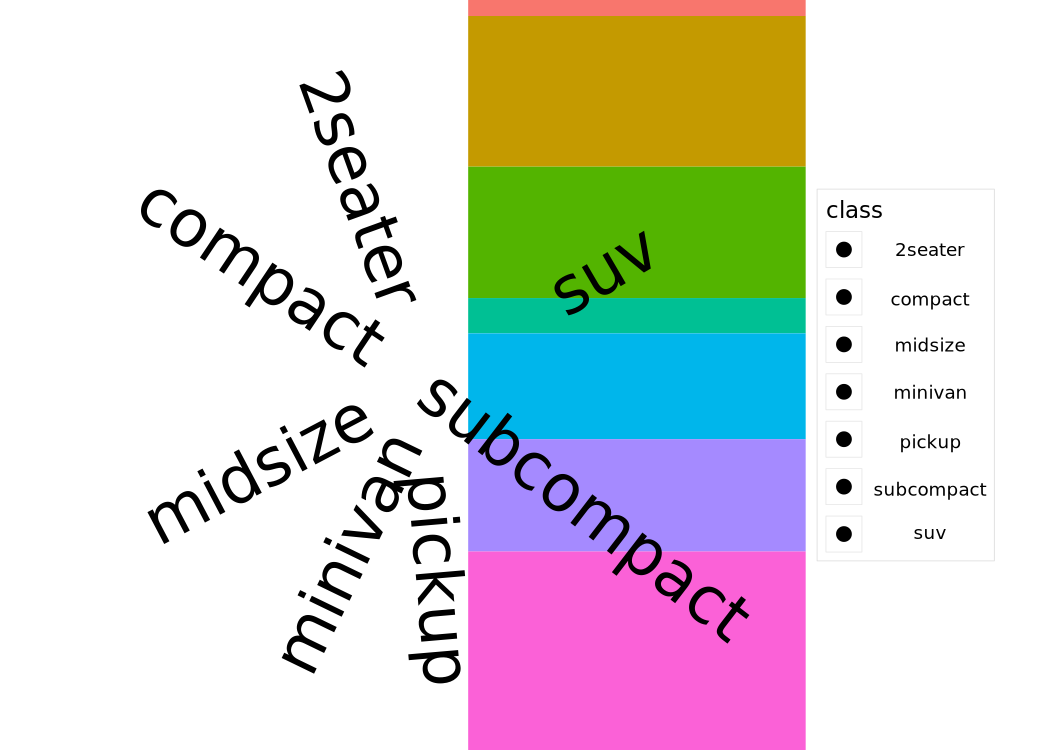

In [10]:
ggplot(mpg2, aes("f1", fill="class")) + geom_bar(show_legend=False, position="fill") + geom_text_aimed(aes(x=1.2, label="class", group="class"), position=position_fill(vjust=0.5), stat="count") + coord_polar("y") + theme_void()

## Axes inside the panel — `coord_axes_inside`

Moves the axes to the origin (here data centred on 0):

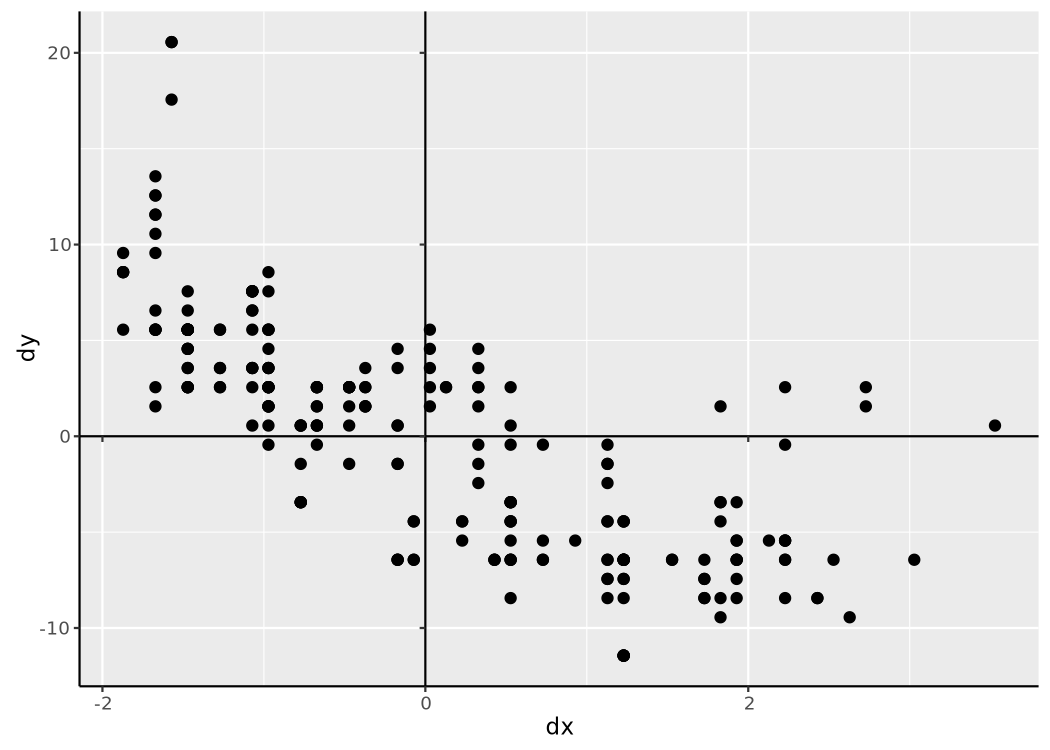

In [11]:
ggplot(mpg3, aes("dx", "dy")) + geom_point() + theme(axis_line=element_line()) + coord_axes_inside()